In [1]:
!pip install torch matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim #optimization algorithms
import matplotlib.pyplot as plt

In [3]:
x = torch.tensor([[1.0],[2.0],[3.0],[4.0],[5.0]]) # inputs
y = torch.tensor([[3.0],[5.0],[7.0],[9.0],[11.0]]) # targets

In [4]:
model = nn.Linear(1,1) #y = wx+b

In [5]:
for name, param in model.named_parameters():
  print(f"{name}")
  print(param.data)
  print("Shape : ",param.shape)
  print("\n")

weight
tensor([[-0.4778]])
Shape :  torch.Size([1, 1])


bias
tensor([0.0882])
Shape :  torch.Size([1])




In [6]:
for param in model.parameters():
  print(param)

Parameter containing:
tensor([[-0.4778]], requires_grad=True)
Parameter containing:
tensor([0.0882], requires_grad=True)


In [7]:
print(f"initial weight : {model.weight.data}")
print(f"intial bias : {model.bias.data}")

initial weight : tensor([[-0.4778]])
intial bias : tensor([0.0882])


In [8]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(),lr = 0.01)
print("criterion is this : ",criterion)
print("\n")
print(optimizer)

criterion is this :  MSELoss()


SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


In [9]:
with torch.no_grad():
  preds = model(x)

In [10]:
print("before training")
print(preds)

before training
tensor([[-0.3896],
        [-0.8673],
        [-1.3451],
        [-1.8229],
        [-2.3007]])


In [11]:
epochs = 20
losses = []
for epoch in range(epochs):

  #forward pass
  predictions = model(x)

  # calculate loss
  loss = criterion(predictions, y)

  #backward pass # dw
  optimizer.zero_grad()
  loss.backward()

  #update weights - new weight = old weight - lr*dw
  optimizer.step()

  losses.append(loss.item())

  if epoch%2 == 0 :
    print(f"Epoch {epoch},Loss : {loss.item():.4f}")

Epoch 0,Loss : 81.9198
Epoch 2,Loss : 27.8250
Epoch 4,Loss : 9.4544
Epoch 6,Loss : 3.2157
Epoch 8,Loss : 1.0970
Epoch 10,Loss : 0.3774
Epoch 12,Loss : 0.1330
Epoch 14,Loss : 0.0499
Epoch 16,Loss : 0.0217
Epoch 18,Loss : 0.0120


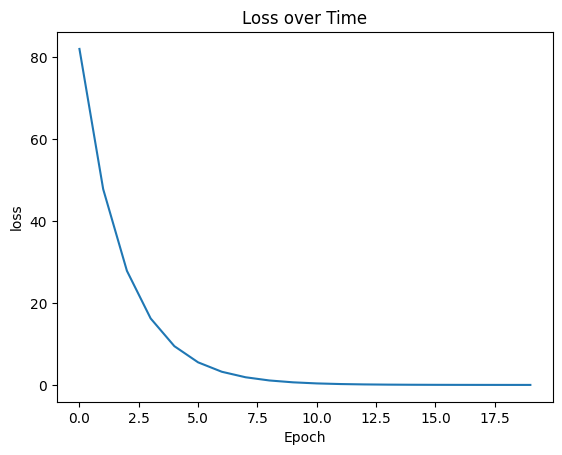

In [12]:
plt.plot(losses)
plt.title("Loss over Time")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.show()

In [13]:
print("trained weight :", model.weight.data)
print("trained bias : ", model.bias.data)

trained weight : tensor([[2.0428]])
trained bias :  tensor([0.8011])


In [14]:
with torch.no_grad():
  preds = model(x)

print("Predictions after training :",preds)

Predictions after training : tensor([[ 2.8439],
        [ 4.8866],
        [ 6.9294],
        [ 8.9721],
        [11.0149]])


In [15]:
z = torch.tensor([[9.0]])

In [16]:
with torch.no_grad():
  pred_1 = model(z)

print("For unseen data : ",pred_1)

For unseen data :  tensor([[19.1859]])


In [17]:
model_high_lr = nn.Linear(1,1)
optimizer_high = optim.SGD(model_high_lr.parameters(),lr = 1.0)

In [18]:
with torch.no_grad():
  preds = model_high_lr(x)

In [19]:
print("before training")
print(preds)

before training
tensor([[-0.5509],
        [-0.4868],
        [-0.4227],
        [-0.3586],
        [-0.2945]])


In [20]:
epochs = 20
losses_high = []
for epoch in range(epochs):

  #forward pass
  predictions_high = model_high_lr(x)

  # calculate loss
  loss_high = criterion(predictions_high, y)

  #backward pass # dw
  optimizer_high.zero_grad()
  loss_high.backward()

  #update weights - new weight = old weight - lr*dw
  optimizer_high.step()

  losses_high.append(loss_high.item())

  if epoch%2 == 0 :
    print(f"Epoch {epoch},Loss : {loss_high.item():.4f}")

Epoch 0,Loss : 62.5923
Epoch 2,Loss : 16460256.0000
Epoch 4,Loss : 4341323530240.0000
Epoch 6,Loss : 1145005982959534080.0000
Epoch 8,Loss : 301990494309194462658560.0000
Epoch 10,Loss : 79648727028495742456985288704.0000
Epoch 12,Loss : 21007017998606739201775055264546816.0000
Epoch 14,Loss : inf
Epoch 16,Loss : inf
Epoch 18,Loss : inf


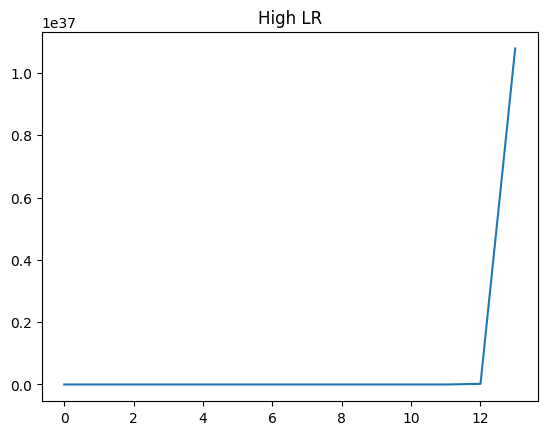

In [21]:
plt.plot(losses_high)
plt.title("High LR")
plt.show()

In [29]:
model_low_lr = nn.Linear(1,1)
optimizer_low = optim.SGD(model_low_lr.parameters(),lr = 0.0001)
with torch.no_grad():
  preds = model_low_lr(x)
print("before training")
print(preds)

before training
tensor([[0.1559],
        [0.2655],
        [0.3750],
        [0.4846],
        [0.5942]])


In [30]:
epochs = 20
losses_low = []
for epoch in range(epochs):

  #forward pass
  predictions_low = model_low_lr(x)

  # calculate loss
  loss_low = criterion(predictions_low, y)

  #backward pass # dw
  optimizer_low.zero_grad()
  loss_low.backward()

  #update weights - new weight = old weight - lr*dw
  optimizer_low.step()

  losses_low.append(loss_low.item())

  if epoch%2 == 0 :
    print(f"Epoch {epoch},Loss : {loss_low.item():.4f}")

Epoch 0,Loss : 51.0374
Epoch 2,Loss : 50.5563
Epoch 4,Loss : 50.0798
Epoch 6,Loss : 49.6077
Epoch 8,Loss : 49.1402
Epoch 10,Loss : 48.6770
Epoch 12,Loss : 48.2182
Epoch 14,Loss : 47.7637
Epoch 16,Loss : 47.3135
Epoch 18,Loss : 46.8675


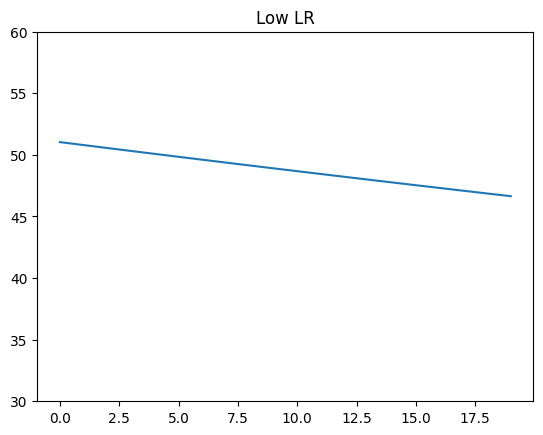

In [34]:
plt.ylim(30,60)
plt.plot(losses_low)
plt.title("Low LR")
plt.show()

In [35]:
text_data = [
    ("hi","hello"),
    ("how are you","i am fine"),
    ("who are you","i am bot")
]

In [37]:
t = (1,1,2,2,2,3,3,3,2,1,2,4,5,4,5)
a = set(t)
print(len(a))

5


In [41]:
for inp, out in text_data :
  print(inp,"->",out)


hi -> hello
how are you -> i am fine
who are you -> i am bot


In [42]:
vocab = set()
for inp, out in text_data :
  vocab.update(inp.split())
  vocab.update(out.split())

In [43]:
print(vocab)

{'are', 'you', 'i', 'hello', 'hi', 'fine', 'am', 'bot', 'who', 'how'}


In [44]:
vocab = list(vocab)

In [45]:
print(vocab)

['are', 'you', 'i', 'hello', 'hi', 'fine', 'am', 'bot', 'who', 'how']


In [48]:
a = ["a","b","c"]
for i,j in enumerate(a) :
  print(i,"->",j)

0 -> a
1 -> b
2 -> c


In [49]:
word2idx = {w : i for i, w in enumerate(vocab)}
idx2word = {i : w for w, i in word2idx.items()}

print(word2idx)
print(idx2word)

{'are': 0, 'you': 1, 'i': 2, 'hello': 3, 'hi': 4, 'fine': 5, 'am': 6, 'bot': 7, 'who': 8, 'how': 9}
{0: 'are', 1: 'you', 2: 'i', 3: 'hello', 4: 'hi', 5: 'fine', 6: 'am', 7: 'bot', 8: 'who', 9: 'how'}


In [50]:
print(word2idx)

{'are': 0, 'you': 1, 'i': 2, 'hello': 3, 'hi': 4, 'fine': 5, 'am': 6, 'bot': 7, 'who': 8, 'how': 9}


In [54]:
print(word2idx["are"])
print(word2idx["bot"])

0
7


In [56]:
def encode(sentence):
  return torch.tensor([word2idx[w] for w in sentence.split()])

In [57]:
encode("hi how are you")

tensor([4, 9, 0, 1])

In [58]:
pairs_ = []
for inp,out in text_data :
  pairs_.append([encode(inp),encode(out)])

print(pairs_)

[[tensor([4]), tensor([3])], [tensor([9, 0, 1]), tensor([2, 6, 5])], [tensor([8, 0, 1]), tensor([2, 6, 7])]]


In [60]:
pairs = [(encode(inp),encode(out)) for inp, out in text_data]
print(pairs)

[(tensor([4]), tensor([3])), (tensor([9, 0, 1]), tensor([2, 6, 5])), (tensor([8, 0, 1]), tensor([2, 6, 7]))]


In [61]:
class TinyModel(nn.Module) :
  def __init__(self,vocab_size):
    super().__init__()
    self.embed = nn.Embedding(vocab_size,8)
    self.linear = nn.Linear(8,vocab_size)

  def forward(self,x) :
    x = self.embed(x)
    x = x.mean(dim = 0) # pooling - combines word vectors into one representation
    return self.linear(x)


In [62]:
model_text = TinyModel(len(vocab))
criterion = nn.CrossEntropyLoss()


In [64]:
for name, param in model_text.named_parameters():
  print(f"{name}")
  print(param.data)
  print("Shape : ",param.shape)
  print("\n")


for param in model_text.parameters():
  print(param)



embed.weight
tensor([[-1.8788, -1.0087, -0.5360, -0.2346, -0.5686,  0.8247,  0.3098,  0.3184],
        [ 0.6727, -1.3003,  0.3227, -0.1369,  0.3865, -1.0799,  2.2215,  0.0743],
        [-1.2221, -0.9905,  0.4112,  0.8565,  0.6058, -0.2829,  0.8534, -1.2146],
        [-0.6827, -1.0738, -0.1405,  1.1274,  1.7209,  0.1411,  0.0867,  0.0684],
        [ 0.3545, -0.4727,  0.2711, -0.9013,  0.3626, -0.6669, -0.0691,  0.2861],
        [ 1.9348,  0.3777, -1.2642, -1.0876,  0.8418,  0.7721, -0.8417, -0.0626],
        [-2.3456, -0.4497,  0.2436,  0.6555, -0.2179, -2.0764, -0.2833,  0.8039],
        [ 0.1885,  1.0572, -0.1501,  0.0215,  0.3321,  1.0925, -0.1510, -1.5434],
        [-1.4286, -1.7321, -1.1924,  1.2515, -0.2431,  0.4761,  0.5102, -0.3654],
        [-0.6089, -0.0782, -1.2616, -2.0743, -0.0917,  0.4679, -1.9099,  0.7735]])
Shape :  torch.Size([10, 8])


linear.weight
tensor([[ 0.0308, -0.3115,  0.0885,  0.1685, -0.2303, -0.0641, -0.0507,  0.1424],
        [-0.0125, -0.1192, -0.3521, -0.

In [65]:
optimizer = optim.Adam(model_text.parameters(),lr = 0.01)

In [66]:
for epoch in range(200):
  total_loss = 0

  for inp,out in pairs :
    # forward pass
    pred = model_text(inp)

    # calculate loss
    loss = criterion(pred.unsqueeze(0),out[0].unsqueeze(0))

    # calculate dw & backward pass
    optimizer.zero_grad()
    loss.backward()

    # re update the weights
    optimizer.step()

    total_loss = total_loss  +loss.item()

  if epoch % 10 == 0:
    print(f"Epoch {epoch}, Loss : {total_loss:.4f}")

Epoch 0, Loss : 7.3060
Epoch 10, Loss : 2.4141
Epoch 20, Loss : 0.4935
Epoch 30, Loss : 0.1576
Epoch 40, Loss : 0.0808
Epoch 50, Loss : 0.0513
Epoch 60, Loss : 0.0360
Epoch 70, Loss : 0.0269
Epoch 80, Loss : 0.0210
Epoch 90, Loss : 0.0169
Epoch 100, Loss : 0.0139
Epoch 110, Loss : 0.0117
Epoch 120, Loss : 0.0099
Epoch 130, Loss : 0.0086
Epoch 140, Loss : 0.0075
Epoch 150, Loss : 0.0066
Epoch 160, Loss : 0.0059
Epoch 170, Loss : 0.0052
Epoch 180, Loss : 0.0047
Epoch 190, Loss : 0.0043


In [69]:
def predict(sentence):
  inp = encode(sentence)

  with torch.no_grad() :
    out = model_text(inp)
  idx = out.argmax().item()
  return idx2word[idx]



In [83]:
print("hi->",predict("hi"))
print("fine->",predict("fine"))

hi-> hello
fine-> am


In [84]:
print("am->",predict("are am bot"))

am-> i


In [81]:
print("hi ->",predict("hi"))
print("bot->", predict("bot"))


hi -> hello
bot-> hi


In [71]:
print("whats your name ->",predict("whats your name")) # because "whats" is not there in the vocab

KeyError: 'whats'

In [85]:
!pip install sentence-transformers

In [87]:
!pip install transformers

In [88]:
from transformers import pipeline


model = pipeline("sentiment-analysis")
print(model("AI is great"))


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

[{'label': 'POSITIVE', 'score': 0.9997223019599915}]


In [ ]:
labels = ["sports","entertainment"]